In [1]:
#from scipy import constants as const
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [10, 5]

import oreonspy as op

# Dynamics of fields in a Fabry-Perot cavity

The dynamics are described by the difference equation (Rakhmanov Eq. 1.50):

$E(t) = t_a E_\mathrm{in}(t) + r_a r_b e^{-2 i k d(t)} E(t-2T)$

where:
* $t_a$ is the transmissivity of the input mirror;
* $E_\mathrm{in}(t)$ is input laser field;
* $r_a$ and $r_b$ are the reflectivities of the mirrors (a - input, b - output);
* $k = \omega / c = 2\pi / \lambda$ is the wavenumber;
* $d(t) = L + x_b(t-T) - x_a(t) = L + \xi$ is physical length of the cavity (Rakhmanov Eq. 1.33);
* $T = \frac{L}{c}$ is half of the round-trip time;
* $L$ is half of the round-trip;
* $E(t-2T)$ is the field inside the cavity at the time before one round-trip.

## Finesse and cavity decay time

Coefficient of finesse:

$F = \frac{4 r_a r_b}{(1 - r_a r_b)^2}$

$\tau_s = \frac{FL}{c\pi}$

Finesse ($\mathcal{F}$) of the cavity:

$\mathcal{F} = \frac{\pi}{2} \sqrt{F}$

Approximately: $\mathcal{F} = \pi N_\mathrm{eff}$

## Cavity gain

$E = g A$

where $g$ ia the amplitude gain of the Fabry-Perot cavity:

$g = \frac{t_a}{1-r_a r_b}$

Power gain:

$P = g^2 P_\mathrm{in}$

In [2]:
# LASER
E_in_avg = 1  #
lambd = 1064e-9  # m
k = 2.*np.pi / lambd

In [3]:
def v_cr(cavity):
    return lambd / (2. * cavity.Finesse() * cavity.tau())  # In [m/s]!

In [20]:
TEst = op.Cavity(t_a = 0.1, r_a = 0.9, r_b = 0.9, L=3000., debug=False)
TEst.simulation(k, 1450e3)
TEst.print_sim_params()
#TEst.plot_sim_factors()

Theta: 6.90e-07 [s]
Cavity RT: 2.00e-05 [s]
N_eff: 5.00e+00 [s]
N: 1


2.4637934543840106e-11


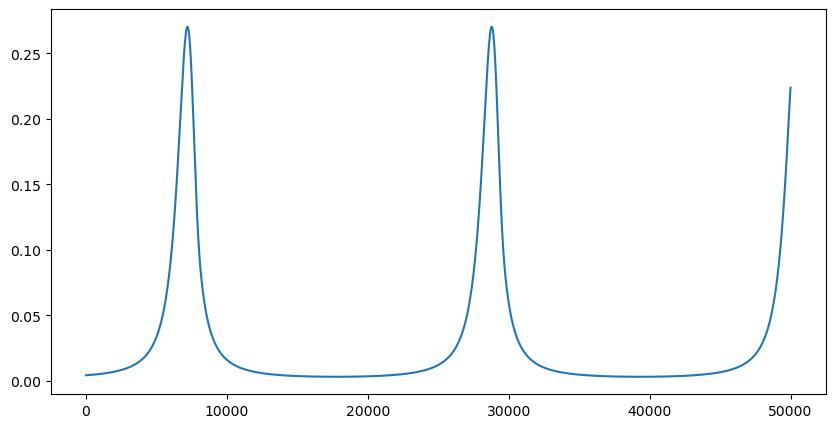

In [22]:
v = 0.1*v_cr(TEst)
d_zeta = v*TEst.Theta
points=50000
s = np.zeros(points)
for i in range(points):
    s[i] = np.abs(TEst.sim_step(d_zeta, E_in_curr=1.))**2

print(d_zeta)
plt.plot(s)

## Cavity parameters summary

### ARM cavity

TODO:
Verify the parameters!!!

* ifo.Optics.ITM.Transmittance  = 0.014;             % Transmittance of ITM
* ifo.Optics.ETM.Transmittance  = 5e-6;              % Transmittance of ETM
* ifo.Optics.SubstrateAbsorption = 0.3e-4;              % 1/m; bulk absorption coef
* ifo.Optics.ITM.CoatingAbsorption = 1.0e-6;            % absorption of ITM
* ifo.Materials.MassThickness = 0.2;                   % m;

In [32]:
MassThickness = 0.2                   # m
SubstrateAbsorption = 0.3e-4          # 1/m; bulk absorption coef
MirrorSubstrateAbsorption = SubstrateAbsorption * MassThickness

t_a = 0.014
r_a = np.sqrt(1. - MirrorSubstrateAbsorption**2 - t_a**2)

t_b = 5e-6
r_b = np.sqrt(1. - t_b**2)

L = np.ceil(3000.0/lambd)*lambd - 0.05*lambd

ARM = op.Cavity(t_a = t_a, r_a = r_a, r_b = r_b, L = L)
ARM.print_params()

Coefficient of finesse: 416411237.01
Half round-trip time: 1.00e-05 [s]
Effective number of photon round trip: 10203
Tau_s: 1.33e+03 [s]
Finesse: 32053.92
Gain: 142.85


In [38]:
ARM.simulation(k, 100/ARM.T, E_last=0.0006)
ARM.print_sim_params()

Theta: 1.00e-07 [s]
Cavity RT: 2.00e-05 [s]
N_eff: 1.02e+04 [s]
N: 1


8.133409762014675e-18


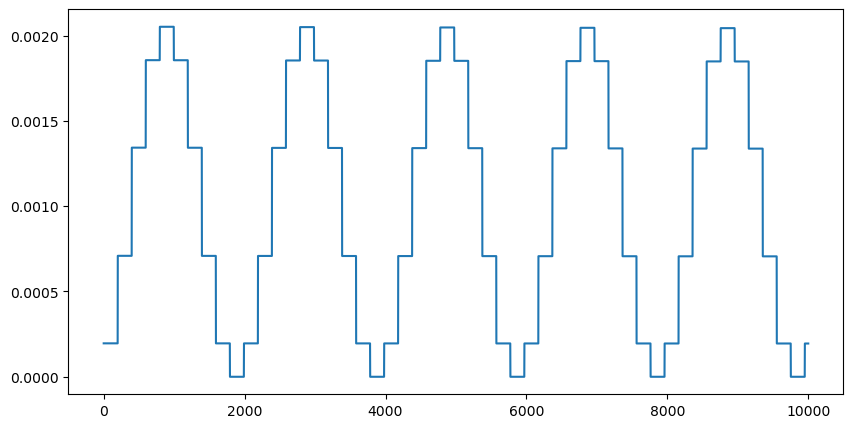

In [39]:
v = 1*v_cr(ARM)
d_zeta = v*ARM.Theta
points=10000
s = np.zeros(points)
for i in range(points):
    s[i] = np.abs(ARM.sim_step(d_zeta, E_in_curr=1.))**2

print(d_zeta)
plt.plot(s)

### Filter cavity

In [10]:
L = np.ceil(284.9/lambd)*lambd - 0.05*lambd
FC = op.Cavity(t_a = 0.000562, r_a = 0.9998398, r_b = 0.99983999, L = L)

'''
# Finesse 9582-10204  # Thermal detuning of a bichromatic narrow linewidth optical cavity L.D. BONAVENA
t_a = 0.000562
t_b = 0.00000316  # Thermal detuning of a bichromatic narrow linewidth optical cavity L.D. BONAVENA
r_a = np.sqrt(1. - t_a**2)-0.00016
r_b = np.sqrt(1. - t_b**2)-0.00016
L = 284.9  # m
L = 284.9  # m
'''

FC.print_params()

Coefficient of finesse: 39005034.74
Half round-trip time: 9.50e-07 [s]
Effective number of photon round trip: 3123
Tau_s: 1.18e+01 [s]
Finesse: 9810.25
Gain: 1.76


In [15]:
FC.simulation(k, 100450e3)
FC.print_sim_params()

Theta: 9.96e-09 [s]
Cavity RT: 1.90e-06 [s]
N_eff: 3.12e+03 [s]
N: 1


9.095105757046422e-18


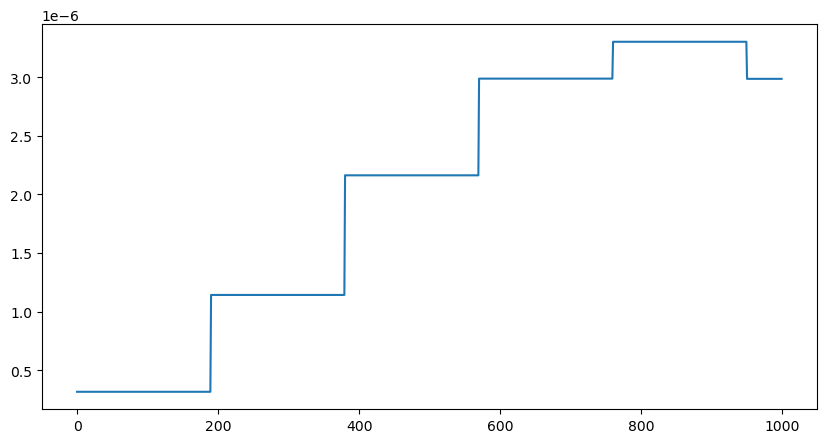

In [16]:
v = 0.1*v_cr(FC)
d_zeta = v*FC.Theta
points=1000
s = np.zeros(points)
for i in range(points):
    s[i] = np.abs(FC.sim_step(d_zeta, E_in_curr=1.))**2

print(d_zeta)
plt.plot(s)

### Mode cleaner cavity

In [ ]:
L = np.ceil(.5/lambd)*lambd - 0.05*lambd
MC = op.Cavity(t_a = 0.000562, r_a = 0.9998398, r_b = 0.99983999, L = L)

'''
'''

MC.print_params()

In [ ]:
MC.simulation(k, 1450e3)
MC.print_sim_params()

In [ ]:
v = 0.1*v_cr(MC)
d_zeta = v*MC.Theta
points=10000
s = np.zeros(points)
for i in range(points):
    s[i] = np.abs(MC.sim_step(d_zeta, E_in_curr=1.))**2

print(d_zeta)
plt.plot(s)

## Critical velocity

$v_\mathrm{cr} = \frac{\lambda}{2\tau\mathcal{F}}$

where $\tau$ is the storage time:

$\tau = 2 T N_\mathrm{eff}$

In [ ]:
def v_cr(cavity):
    return lambd / (2. * cavity.Finesse() * cavity.tau())  # In [m/s]!

In [ ]:
v_cr(ARM)

In [ ]:
v_cr(FC)

In [ ]:
v_cr(MC)

## Airy function

In [ ]:
def Airy(F, phi):
    return 1. / (1. + F * np.sin(phi)**2)

# Cavity state sampling

This section is dedicated to the data acquisition which collects available information about the cavity such as: reflected optical power, trasmitted optical power and Pound-Drever-Hall error signal.

For efficient data treatment we consider placing the data into rolling buffers. Our first estimation of the buffer length is based on the cavity storage time $\tau$ and the sampling rate.

* sampling rate
* sampling interval
* useful past samples - considering the fact that the cavity storage time is known, there exists a maximum number of past samples usefull in the state estimation

Attempt for an efficient python circular buffer implementation:

    import collections
    d = collections.deque(maxlen=10)

    deque([], maxlen=10)
    for i in xrange(20):
        d.append(i)

In [ ]:
class cavity_sampling():
    def __init__(self, cav, sampling_rate = 100e3):
        self.cavity = cav
        self.sampling_rate = sampling_rate
        sampling_interval = 1./sampling_rate
        usefull_past_samples = int(np.ceil(cav.tau_s()/sampling_rate))
        number_of_RT_between_samples = sampling_rate*(2.*cav.T)
        print("Optimal sampling: {0:.2e} [Hz]".format(1./(2.*cav.T)))
        print("Sampling rate [SPS]: {0}".format(sampling_rate))
        print("Sampling inteval [s]: {0}".format(sampling_interval))
        print("Usefull past samples [#]: {0}".format(usefull_past_samples))
        print("Number of round-trips between samples [#]: {0}".format(number_of_RT_between_samples))

cavity_sampling(TEst, sampling_rate=68e3)
  # 100kHz

  # s

Numercal simulation needs values read by ADC at much higher sampling rate. Assuming slowly varying signals we interpolate the missing values.

In [ ]:
#np.interp()

## Some cases of $d(t)$

* $d(t) = const.$
* $d(t) = A\sin(2\pi f t)$
* $d(t) = arb(t)$ -- arbitrary function of time

In [ ]:
#v = 1.e-6/0.1  # m/s

v = 0.1*v_cr(ARM)
#v = 0.00037640

def d(t):
    # Constant
    #return 2

    # Linear
    #c = 1.
    return v*t + L

    # Sinusoidal
    A = 1.e-7
    f = 200.e6  # Hz
    #return A*np.sin(2.*np.pi*f*t)

In [ ]:
def E_in(t):
    return 1.
    #return A*np.sin(2.*np.pi*f*t)

## Implementation of Eq. 1.51

$\large E(t) = t_a \sum_{n=0}^{N-1}(r_a r_b)^n e^{-2ikS_n(t)} E_\mathrm{in}(t-2nT) + (r_a r_b)^N e^{-2ikS_N(t)}E(t-2NT)$


### Factor common to interations, possible to pre-calculate

In [ ]:
def possible_f_calc(cav):
    for i in np.arange(2,10):
        print("One simulation with N = {0} to obtain f_calc: {1:.1f} [Hz]".format(i, 1./(2.*cav.T*i)))
        
    for i in np.arange(1,10):
        print("Make {0} simulations to obtain f_calc: {1:.1f} [Hz]".format(i, i*1./(2.*cav.T)))

possible_f_calc(MC)

## Linear cavity sweep simulation

In [ ]:
d_zeta = v*2.*ARM.T

ARM.simulation(k, 100.e3)
ARM.sim_step(d_zeta, E_in_curr=1.)

In [ ]:
def time_window(v, cavity, number_of_FSR=2.):
    t_stop = number_of_FSR * lambd/(2.*v)
    print("Time window [s]: {0}".format(t_stop))
    number_of_points = int(np.ceil(t_stop/cavity.Theta))
    print("Time window point number: {0}".format(number_of_points))
    return number_of_points, np.linspace(0., t_stop, number_of_points)

#number_of_points, tdata = time_window(v, ARM)


## Definition of useful arrays

## Automation of the comparison between numerical solution and Airy function with selectable velocity.

The function `simulation_check` aims to automatize the process of compare the numerical simulation with the analitycal solution (Airy function), giving the possibility to choose the velocity of $d(t)$ and compute the right time window for visualizing 2 free spectral range. The correct time window is calculated through the function `time_window`.

In [ ]:
def d2(t,v, type):
    if type=="const":
        return 2
    if type=="linear":
        return v*t + L
    if type=="sin":
        A = 1.e-7
        f = 200.e6  # Hz
        return A*np.sin(2.*np.pi*f*t)

In [ ]:
def simulation_check(cav, v, number_of_FSR, f_calc=10.e3):
    cav.simulation(k, f_calc)
    
    d_zeta = v*cav.Theta
    print("d_zeta: {0}".format(d_zeta))

    print("N: {0}".format(cav.N))
    
    points, tdata = time_window(v, cav, number_of_FSR=number_of_FSR)
    ein = np.zeros(points, dtype=np.complex128)
    res = np.zeros(points, dtype=np.complex128)
    Adata = np.zeros(points)
    
    for idx, t in enumerate(tdata):
        ein[idx] = E_in(t)
        res[idx] = cav.sim_step(d_zeta, E_in_curr=1.)
        Adata[idx] = Airy(cav.F(), (t*k*v))

        #print(cav.Ze)

    res = np.abs(res)
    Pdata = Adata * cav.gain()**2  # Eq. 1.76 (Rakhmanov)
    
    return tdata, ein, res, Pdata

In [ ]:
v = 2*v_cr(TEst)

tdata, ein, res, Adata = simulation_check(TEst, v, 1, f_calc=250e3)

In [ ]:
plt.figure()
#plt.plot(tdata, np.abs(res)**2, label="Numerical magn")
#plt.plot(tdata, Adata, label="Airy")

length = len(tdata)
start_pr = int(length*0.6)
stop_pr = int(length*1)
plt.plot(res[start_pr:stop_pr]**2, label="Numerical magn")
plt.plot(Adata[start_pr:stop_pr], label="Airy")
#plt.xlim(-0.01,0.07)
plt.xlabel("Time [s]")
plt.legend()

#plt.figure()
#plt.plot(tdata, np.angle(res,deg=True), label="Numerical phase")
#plt.plot(tdata, np.angle(res, deg=True), label="Numerical phase")
#plt.xlabel("Time [s]")
#plt.legend()

plt.savefig("sampl_250kHz.png")
plt.show()

In [ ]:
TEst.plot_sim_factors()

If you want to keep your original phase with pi-periodicity, you should first double the phase, unwrap it, then divide it by two.

# TODO:
    1. 